# Lab 00 — Setup & sanity (interactive)

Prove the chain works and *see* nearest-neighbour search in raw SQL.

**Before running:** `./tunnel.sh` in a terminal.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "00_setup")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
print("labs root:", LABS)

labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs


## Connect & confirm pgvector

In [2]:
from shared.db import connect

with connect() as conn, conn.cursor() as cur:
    cur.execute("select current_database(), current_user")
    print("connected:", cur.fetchone())
    cur.execute("select extversion from pg_extension where extname='vector'")
    print("pgvector:", cur.fetchone()[0])

connected: ('rag_lab', 'rag')
pgvector: 0.8.6


## A vector round-trip — kNN in plain SQL
`<=>` is cosine distance; `ORDER BY ... LIMIT k` is nearest-neighbour search.

In [3]:
import numpy as np

rows = [(1, "apple", np.array([1., 0, 0])),
        (2, "banana", np.array([.9, .1, 0])),
        (3, "rocket", np.array([0., 0, 1]))]
q = np.array([1., 0, 0])
with connect() as conn, conn.cursor() as cur:
    cur.execute("drop table if exists _nb00")
    cur.execute("create table _nb00 (id int, name text, embedding vector(3))")
    cur.executemany("insert into _nb00 values (%s,%s,%s)", rows)
    cur.execute("select name, embedding <=> %s as d from _nb00 order by d", (q,))
    res = cur.fetchall()
    cur.execute("drop table _nb00")
    conn.commit()
res

[('apple', 0.0), ('banana', 0.006116251198662548), ('rocket', 1.0)]

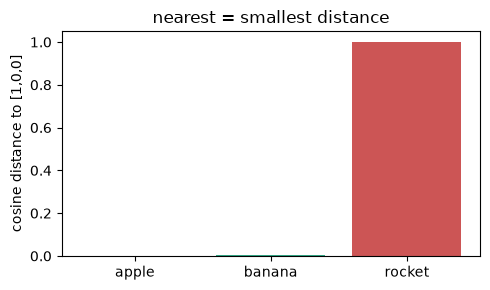

In [4]:
import matplotlib.pyplot as plt

names = [r[0] for r in res]
dists = [float(r[1]) for r in res]
plt.figure(figsize=(5, 3))
plt.bar(names, dists, color=["#33aa88", "#33aa88", "#cc5555"])
plt.ylabel("cosine distance to [1,0,0]")
plt.title("nearest = smallest distance")
plt.tight_layout()
plt.show()

`apple` (identical direction) → 0, `banana` (close) → tiny, `rocket` (orthogonal) → 1. That ordering *is* retrieval. Next: real embeddings in Lab 01.